In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_style("white")
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch as pt

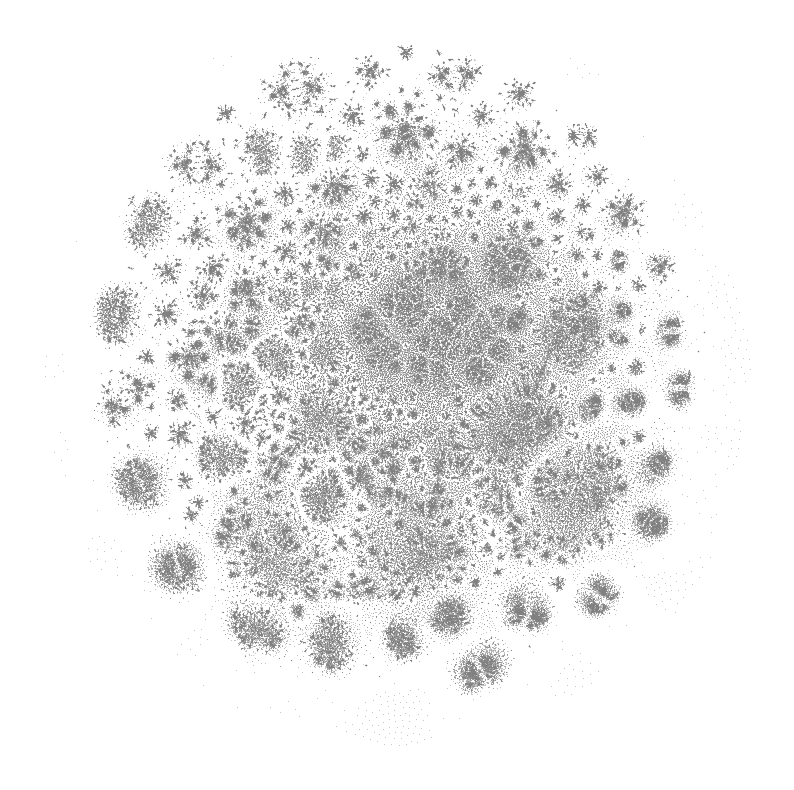

In [3]:
red = 'tsne'
model_name = 'ohe'
dataset_size = '399990'


if model_name == 'antiberta2':
    short_model_name = 'ab2'
else:
    short_model_name = model_name


if int(dataset_size) >= 300_000:
    s_size = 0.6
    alpha_p = 0.5
elif 200_000 <= int(dataset_size) < 300_000:
    s_size = 0.8
    alpha_p = 0.5
elif 100_000 <= int(dataset_size) < 150_000:
    s_size = 0.8
    alpha_p = 0.7
elif 50_000 <= int(dataset_size) < 100_000:
    s_size = 0.8
    alpha_p = 0.9
elif 0 <= int(dataset_size) < 50_000:
    s_size = 0.9
    alpha_p = 1.0


df = pd.DataFrame(pd.read_pickle(f'<UPDATE_PATH>'  # TODO: update path to your data).values)
df.columns = ['x', 'y']

# Create the scatterplot
plt.figure(figsize=(10, 10))
scatter = sns.scatterplot(data=df, x='x', y='y', s=s_size, linewidth=0, alpha=alpha_p, color='grey'), #hue='dataset')

# Set axes' names
plt.xlabel(f'{red}_1', fontsize=20)
plt.ylabel(f'{red}_2', fontsize=20)

# Remove the spines
sns.despine(left=True, bottom=True)
plt.xticks([])
plt.yticks([])
plt.xlabel('')
plt.ylabel('')

# Save and show the plot
#plt.savefig(f'/doctorai/marinafr/2023/airr_atlas/analysis/jupyter/{red.upper()}_H_CDR3_{short_model_name}_{dataset_size}.pkl.png')
plt.show()

# **Generate Gaussian data**

In [9]:
# Define parameters
num_points = 399990  # Number of points
dimensionality = 1280  # Dimensionality of the space
chunk_size = 5000  # Process in chunks to avoid memory issues
file_path = f'<UPDATE_PATH>'  # TODO: update path to your data  # Output file

# Open a binary file for writing
with open(file_path, "wb") as f:
    data = np.random.randn(num_points, dimensionality).astype(np.float32)  # Use float32 to save memory
    np.save(f, data)

print(f"Dataset saved to {file_path}")

Dataset saved to /doctorai/marinafr/2023/airr_atlas/analysis/jupyter/gaussian_1280d_399990.npy


In [22]:
subset_size = 10000

subset = data[:subset_size]

file_path = f'<UPDATE_PATH>'  # TODO: update path to your data

with open(file_path, "wb") as f:
    np.save(f, subset)

print(f"Dataset saved to {file_path}")

Dataset saved to /doctorai/marinafr/2023/airr_atlas/analysis/jupyter/gaussian_1280d_10000.npy


In [25]:
dataset_size = '10000'

data = np.load(f'<UPDATE_PATH>'  # TODO: update path to your data)
len(data)

10000

In [55]:
from sklearn.manifold import TSNE
from umap import UMAP

dataset_size = '399990'

data = np.load(f'<UPDATE_PATH>'  # TODO: update path to your data)

#tsne_data = TSNE(random_state=42).fit_transform(data)
tsne_data = pd.DataFrame(UMAP(transform_seed=42, unique=True).fit_transform(data))

output_file = f'<UPDATE_PATH>'  # TODO: update path to your data

# Create a DataFrame with t-SNE results
tsne_df = pd.DataFrame(tsne_data)

# Save the t-SNE result to a pickle file
tsne_df.to_pickle(output_file)
print(f"Saved {output_file}.pkl with {tsne_df.shape[0]} sequences")

tsne_df

Saved /doctorai/marinafr/2023/airr_atlas/analysis/jupyter/UMAP_gaussian_1280d_399990.pkl.pkl with 399990 sequences


,0,1
0,10.778503,3.588253
1,9.101489,5.006021
2,10.636812,3.853951
3,6.811610,4.997925
4,7.170009,5.473133
...,...,...
399985,11.129280,5.844859
399986,9.354811,4.861107
399987,9.614161,5.779815
399988,8.241021,6.026433


In [ ]:
tsne_df = pd.DataFrame(pd.read_pickle(f'<UPDATE_PATH>'  # TODO: update path to your data).values)
tsne_df.columns = ['x', 'y']

tsne_df

,x,y
0,-0.851514,0.150890
1,-1.871451,-0.036402
2,1.186212,-1.879074
3,-1.827009,-1.989276
4,-3.174780,-0.831099
...,...,...
399985,1.202852,-0.688517
399986,2.027363,-0.936227
399987,-0.600593,-3.009740
399988,-2.607918,-0.657330


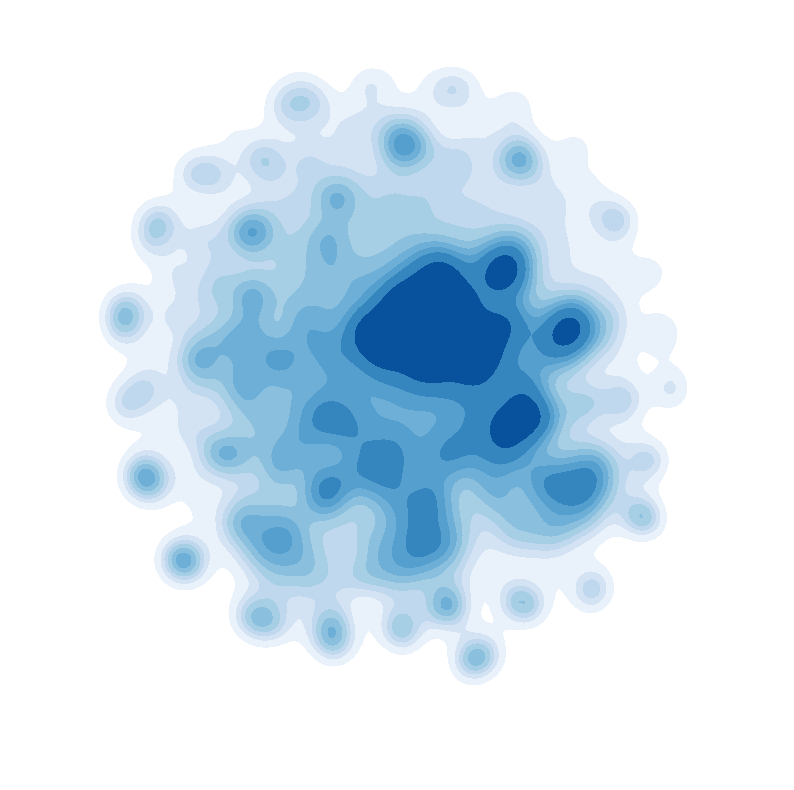

In [14]:
dataset_size = '399990'
model_name = 'ohe'

if model_name == 'antiberta2':
    short_model_name = 'antiberta2'
else:
    short_model_name = model_name


if int(dataset_size) >= 300_000:
    s_size = 0.6
    alpha_p = 0.5
elif 200_000 <= int(dataset_size) < 300_000:
    s_size = 0.8
    alpha_p = 0.5
elif 100_000 <= int(dataset_size) < 150_000:
    s_size = 0.8
    alpha_p = 0.7
elif 50_000 <= int(dataset_size) < 100_000:
    s_size = 0.8
    alpha_p = 0.9
elif 0 <= int(dataset_size) < 50_000:
    s_size = 0.9
    alpha_p = 1.0


df = pd.DataFrame(pd.read_pickle(f'<UPDATE_PATH>'  # TODO: update path to your data).values)
df.columns = ['x', 'y']

# Create the scatterplot
plt.figure(figsize=(10, 10))
#scatter = sns.scatterplot(data=df, x='x', y='y', s=s_size, linewidth=0, alpha=alpha_p, color='grey'), #hue='dataset')
sns.kdeplot(data=df, x='x', y='y', fill=True, alpha=1, cmap="Blues")

# Set axes' names
#plt.xlabel(f'{red}_1', fontsize=20)
#plt.ylabel(f'{red}_2', fontsize=20)

# Remove the spines
sns.despine(left=True, bottom=True)
plt.xticks([])
plt.yticks([])
plt.xlabel('')
plt.ylabel('')

#plt.xlim(-5, 5)
#plt.ylim(-5, 5)

# Save and show the plot
plt.savefig(f'<UPDATE_PATH>'  # TODO: update path to your data)
plt.show()